# 0. Notebook setup

# End‑to‑End ML Project in Microsoft Fabric

This notebook demonstrates a simple but complete machine‑learning workflow using a Lakehouse and Spark:

1. **Data ingestion** – Load raw trip data and lookup data into the Lakehouse.
2. **Data wrangling** – Clean and standardize the raw data.
3. **Feature engineering** – Build a daily feature table for time‑series modeling.
4. **Model experiments & training** – Train a baseline model and an improved model.
5. **Model registry** – Persist the trained model and register it in a Delta‑based table.
6. **Batch inference** – Load the registered model and generate forecasts in batch.

> Assumptions:
> - A default Lakehouse is attached to this notebook.
> - The following files exist in the Lakehouse **Files/**:
>   - `Files/green_tripdata_2022-08.parquet`
>   - `Files/taxi+_zone_lookup.csv`

In [1]:
# PARAMETERS — e2e demo configuration

# Input file paths in the default Lakehouse
raw_parquet_path = "Files/green_tripdata_2022-08.parquet"
lookup_csv_path = "Files/taxi+_zone_lookup.csv"

# Core Delta tables (all tagged for this e2e demo)
raw_table_name = "ml_test_e2e_demo_green_tripdata_2022_08"
clean_table_name = "ml_test_e2e_demo_green_tripdata_2022_08_cleansed"
daily_features_table = "ml_test_e2e_demo_average_fare_per_day"
registry_table = "ml_test_e2e_demo_time_series_model_registry"
predictions_table = "ml_test_e2e_demo_average_fare_forecast"
scoring_log_table = "ml_test_e2e_demo_scoring_runs"

# Model configuration
model_name = "ml_test_e2e_demo_sarimax_average_fare_per_day_with_exog"
model_version = "v1"  # In a real project, this would be incremented
forecast_horizon = 5   # number of future steps to forecast


StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 3, Finished, Available, Finished, False)

In [2]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col
import pandas as pd
import statsmodels.api as sm
import joblib
import os
import json
import uuid
import datetime as dt

import mlflow  # Used where available; if MLflow is not fully configured, we still use our Delta-based registry

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 4, Finished, Available, Finished, False)

# 1. Data ingestion

In [3]:
# 1.1 Load raw trip data (Parquet) from Lakehouse Files into Spark

# Uses raw_parquet_path from the PARAMETERS cell
trips_raw_df = spark.read.parquet(raw_parquet_path)

print("Raw trip data sample:")
display(trips_raw_df.limit(5))

print("Raw trip row count:", trips_raw_df.count())

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 5, Finished, Available, Finished, False)

Raw trip data sample:


SynapseWidget(Synapse.DataFrame, bc91960a-603c-462d-9e35-f84005ac5543)

Raw trip row count: 65929


In [4]:
# 1.2 Persist raw trip data as a Delta table in the Lakehouse

# Uses raw_table_name from the PARAMETERS cell
trips_raw_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(raw_table_name)

print(f"Raw trip data saved as Delta table: {raw_table_name}")

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 6, Finished, Available, Finished, False)

Raw trip data saved as Delta table: ml_test_e2e_demo_green_tripdata_2022_08


In [5]:
# 1.3 Load taxi zone lookup data (CSV) from Lakehouse Files

# Uses lookup_csv_path from the PARAMETERS cell
zones_df = (
    spark.read.format("csv")
    .option("header", "true")
    .load(lookup_csv_path)
)

print("Taxi zone lookup sample:")
display(zones_df.limit(5))

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 7, Finished, Available, Finished, False)

Taxi zone lookup sample:


SynapseWidget(Synapse.DataFrame, 450f927d-de83-4a97-b11f-3cff5cc7f78b)

# 2. Data wrangling / cleaning

In [6]:
# 2.1 Load raw table
trips_df = spark.read.table(raw_table_name)

print("Raw trips schema:")
trips_df.printSchema()

# 2.2 Apply basic data quality rules
# - Remove trips with non‑positive distance or fare
# - Normalize store_and_fwd_flag to boolean
# - Cast pickup/dropoff to timestamp

initial_count = trips_df.count()

trips_clean_df = trips_df.filter(
    (col("trip_distance") > 0) &
    (col("fare_amount") > 0)
)

clean_count = trips_clean_df.count()
removed_count = initial_count - clean_count

trips_clean_df = (
    trips_clean_df
    .withColumn(
        "store_and_fwd_flag",
        F.when(col("store_and_fwd_flag") == "Y", F.lit(True)).otherwise(F.lit(False))
    )
    .withColumn("lpep_pickup_datetime", col("lpep_pickup_datetime").cast("timestamp"))
    .withColumn("lpep_dropoff_datetime", col("lpep_dropoff_datetime").cast("timestamp"))
)

print(f"Initial row count: {initial_count}")
print(f"Clean row count:    {clean_count}")
print(f"Removed rows:       {removed_count}")

display(trips_clean_df.limit(5))

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 8, Finished, Available, Finished, False)

Raw trips schema:
root
 |-- VendorID: long (nullable = true)
 |-- lpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- lpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- ehail_fee: integer (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- payment_type: double (nullable = true)
 |-- trip_type: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)

Initial row count: 65929
Clean row count:    61168
Removed rows:      

SynapseWidget(Synapse.DataFrame, a8fbfe63-b759-41c6-a94b-bcc32dba4e8f)

In [7]:
# 2.3 Persist cleansed data as a Delta table

# Uses clean_table_name from the PARAMETERS cell
trips_clean_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(clean_table_name)

print(f"Cleansed trips saved as Delta table: {clean_table_name}")

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 9, Finished, Available, Finished, False)

Cleansed trips saved as Delta table: ml_test_e2e_demo_green_tripdata_2022_08_cleansed


# 3. Feature engineering (daily features)

In [8]:
# 3.1 Load cleansed data
# Uses clean_table_name from the PARAMETERS cell
trips_clean_df = spark.read.table(clean_table_name)

# 3.2 Aggregate to daily level
# Target (y):      daily average fare_amount
# Features (exog): daily avg_trip_distance, daily trip_count

daily_features_df = (
    trips_clean_df
    .groupBy(F.to_date("lpep_pickup_datetime").alias("pickup_date"))
    .agg(
        F.avg("fare_amount").alias("average_fare"),
        F.avg("trip_distance").alias("avg_trip_distance"),
        F.count("*").alias("trip_count"),
    )
    .orderBy("pickup_date")
)

print("Daily feature sample:")
display(daily_features_df.limit(10))

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 10, Finished, Available, Finished, False)

Daily feature sample:


SynapseWidget(Synapse.DataFrame, a13a317c-cf98-4eb6-adb2-1f75af5e7420)

In [9]:
# 3.3 Persist daily features as a Delta table

# Uses daily_features_table from the PARAMETERS cell

daily_features_df.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable(daily_features_table)

print(f"Daily features saved as Delta table: {daily_features_table}")

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 11, Finished, Available, Finished, False)

Daily features saved as Delta table: ml_test_e2e_demo_average_fare_per_day


# 4. Model experiments & training

In [10]:
# 4.1 Load daily features from Delta
# Uses daily_features_table from the PARAMETERS cell

daily_features_df = spark.read.table(daily_features_table).orderBy("pickup_date")

daily_features_pd = daily_features_df.toPandas()
daily_features_pd["pickup_date"] = pd.to_datetime(daily_features_pd["pickup_date"])
daily_features_pd.set_index("pickup_date", inplace=True)
daily_features_pd.sort_index(inplace=True)

# 4.2 Define target and features
y = daily_features_pd["average_fare"].astype(float)
exog_cols = ["avg_trip_distance", "trip_count"]
X = daily_features_pd[exog_cols].astype(float)

# Drop any rows with NaNs in y or X
valid_mask = y.notna()
for c in exog_cols:
    valid_mask &= X[c].notna()

y = y[valid_mask]
X = X[valid_mask]

n_obs = len(y)
print("Number of observations after cleaning:", n_obs)

if n_obs < 10:
    raise ValueError(f"Not enough data points for robust time‑series modeling (n={n_obs}).")

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 12, Finished, Available, Finished, False)

Number of observations after cleaning: 40


In [11]:
# 4.3 Baseline SARIMA model (no exogenous variables)

baseline_order = (1, 0, 0)
baseline_seasonal_order = (0, 0, 0, 0)

baseline_model = sm.tsa.statespace.SARIMAX(
    y,
    exog=None,
    order=baseline_order,
    seasonal_order=baseline_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

baseline_result = baseline_model.fit(disp=False)

print("Baseline model summary (truncated):")
print(baseline_result.summary().tables[0])
print("\nBaseline AIC:", baseline_result.aic)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 13, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Baseline model summary (truncated):
                               SARIMAX Results                                
Dep. Variable:           average_fare   No. Observations:                   40
Model:               SARIMAX(1, 0, 0)   Log Likelihood                -108.776
Date:                Tue, 21 Jul 2026   AIC                            221.552
Time:                        19:50:25   BIC                            224.879
Sample:                             0   HQIC                           222.746
                                 - 40                                         
Covariance Type:                  opg                                         

Baseline AIC: 221.5521042436126


In [12]:
# 4.4 SARIMAX with exogenous variables (daily avg_trip_distance, trip_count)

if n_obs >= 30:
    order = (1, 1, 1)
    seasonal_order = (1, 1, 1, 7)  # weekly seasonality
else:
    order = (1, 1, 1)
    seasonal_order = (0, 0, 0, 0)

sarimax_model = sm.tsa.statespace.SARIMAX(
    y,
    exog=X,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarimax_result = sarimax_model.fit(disp=False)

print("SARIMAX with exogenous variables summary (truncated):")
print(sarimax_result.summary().tables[0])
print("\nBaseline AIC:", baseline_result.aic)
print("Exogenous SARIMAX AIC:", sarimax_result.aic)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 14, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX with exogenous variables summary (truncated):
                                     SARIMAX Results                                     
Dep. Variable:                      average_fare   No. Observations:                   40
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood                 -24.034
Date:                           Tue, 21 Jul 2026   AIC                             62.067
Time:                                   19:50:32   BIC                             70.016
Sample:                                        0   HQIC                            64.066
                                            - 40                                         
Covariance Type:                             opg                                         

Baseline AIC: 221.5521042436126
Exogenous SARIMAX AIC: 62.06727355674532


In [16]:
# 4.5 Keep modeling flow simple for this demo

# For this end-to-end demo we keep the modeling flow simple and
# rely on the manually configured SARIMAX model from section 4.4.

print("Using manually configured SARIMAX order and seasonal_order:")
print("  order         :", order)
print("  seasonal_order:", seasonal_order)
print("  SARIMAX AIC   :", sarimax_result.aic)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 19, Finished, Available, Finished, False)

Using manually configured SARIMAX order and seasonal_order:
  order         : (1, 1, 1)
  seasonal_order: (1, 1, 1, 7)
  SARIMAX AIC   : 62.06727355674532


In [17]:
# 4.5 Log SARIMAX model to MLflow and register it in the MLflow Model Registry (if available)

mlflow_model_uri = ""  # default if MLflow tracking/registry is not available

try:
    # Use a dedicated experiment for this e2e demo
    mlflow.set_experiment("e2e_demo_average_fare_per_day_sarimax")

    with mlflow.start_run() as run:
        run_id = run.info.run_id
        print("MLflow run_id:", run_id)

        # Log key params and metrics
        mlflow.log_param("order", str(order))
        mlflow.log_param("seasonal_order", str(seasonal_order))
        mlflow.log_param("exog_columns", ",".join(exog_cols))
        mlflow.log_param("n_obs", int(n_obs))

        mlflow.log_metric("train_aic_baseline", float(baseline_result.aic))
        mlflow.log_metric("train_aic_sarimax", float(sarimax_result.aic))

        # Log the statsmodels SARIMAX model as an MLflow artifact
        import mlflow.statsmodels

        artifact_path = "model"
        mlflow.statsmodels.log_model(
            sarimax_result,
            artifact_path=artifact_path,
        )

        # Register the logged model in the MLflow Model Registry
        model_uri_for_registration = f"runs:/{run_id}/{artifact_path}"
        print("Model URI for registration:", model_uri_for_registration)

        registered_model = mlflow.register_model(
            model_uri=model_uri_for_registration,
            name=model_name,  # uses the e2e_demo_ model name from parameters cell
        )

        mlflow_model_uri = f"models:/{registered_model.name}/{registered_model.version}"
        print("Registered MLflow model URI:", mlflow_model_uri)

except Exception as e:
    # Do not break the demo if MLflow tracking/registry is not configured
    print("Warning: MLflow logging/registration failed; continuing with Delta-based registry only.")
    print("MLflow error:", repr(e))

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 20, Finished, Available, Finished, False)

MLflow run_id: 47b03733-6c10-47bc-82f0-e17ec7fe434d
Model URI for registration: runs:/47b03733-6c10-47bc-82f0-e17ec7fe434d/model
Registered MLflow model URI: models:/ml_test_e2e_demo_sarimax_average_fare_per_day_with_exog/1


Successfully registered model 'ml_test_e2e_demo_sarimax_average_fare_per_day_with_exog'.


# 5. Model registry (Delta‑based)

In [18]:
# 5.1 Persist the trained model to the notebook's builtin/ resources

try:
    base_res_path = notebookutils.nbResPath  # Fabric notebook built‑in path
except NameError:
    # Fallback for non‑Fabric environments
    base_res_path = os.path.join(os.getcwd(), "nb_resources")

models_dir = os.path.join(base_res_path, "builtin", "models")
os.makedirs(models_dir, exist_ok=True)

# Uses model_name and model_version from the PARAMETERS cell
local_model_file_path = os.path.join(models_dir, f"{model_name}_{model_version}.joblib")

joblib.dump(sarimax_result, local_model_file_path)
print(f"Model saved locally at: {local_model_file_path}")

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 21, Finished, Available, Finished, False)

Model saved locally at: /synfs/nb_resource/builtin/models/ml_test_e2e_demo_sarimax_average_fare_per_day_with_exog_v1.joblib


In [19]:
# 5.2 Create or append to a Delta‑based model registry

from pyspark.sql import Row

# Simple model selection rule: require some AIC gain vs baseline
aic_gain = baseline_result.aic - sarimax_result.aic
print("AIC improvement vs baseline:", aic_gain)

if aic_gain < 1.0:
    print("AIC improvement too small; skipping registry update.")
else:
    print("AIC improvement sufficient; proceeding to register model.")

    metrics = {
        "train_aic_baseline": float(baseline_result.aic),
        "train_aic_sarimax": float(sarimax_result.aic),
        "aic_gain": float(aic_gain),
        "n_obs": int(n_obs),
    }

    model_registry_row = Row(
        model_name=model_name,
        model_version=model_version,
        model_path=local_model_file_path,
        mlflow_model_uri=mlflow_model_uri,  # now stores MLflow URI if available
        target_series="e2e_demo_average_fare_per_day",
        created_utc=pd.Timestamp.utcnow().isoformat(),
        order=str(order),
        seasonal_order=str(seasonal_order),
        n_obs=int(n_obs),
        exog_columns=",".join(exog_cols),
        stage="Staging",          # demo: initial stage
        status="active",          # demo: active model
        metrics_json=json.dumps(metrics),
    )

    registry_df = spark.createDataFrame([model_registry_row])

    registry_df.write \
        .format("delta") \
        .mode("append") \
        .option("mergeSchema", "true") \
        .saveAsTable(registry_table)

    print(f"Model metadata appended to Delta table: {registry_table}")
    display(registry_df)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 22, Finished, Available, Finished, False)

AIC improvement vs baseline: 159.48483068686727
AIC improvement sufficient; proceeding to register model.
Model metadata appended to Delta table: ml_test_e2e_demo_time_series_model_registry


SynapseWidget(Synapse.DataFrame, 2338350a-7f06-4f75-a427-ce1b793cadd3)

In [20]:
# 5.3 Load the latest model entry from the registry

full_registry_df = spark.read.table(registry_table)
print("Current registry entries:")
display(full_registry_df)

latest_model_row = (
    full_registry_df
    .filter(F.col("stage") == "Staging")  # in a real flow, use "Production"
    .orderBy(F.col("created_utc").desc())
    .limit(1)
    .collect()[0]
)

loaded_model_path = latest_model_row["model_path"]
loaded_model_name = latest_model_row["model_name"]
loaded_model_version = latest_model_row["model_version"]

print(f"Loading model '{loaded_model_name}' version '{loaded_model_version}' from:")
print(loaded_model_path)

loaded_model = joblib.load(loaded_model_path)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 23, Finished, Available, Finished, False)

Current registry entries:


SynapseWidget(Synapse.DataFrame, cc236db5-7144-4c83-aba4-a09e0bc75eb8)

Loading model 'ml_test_e2e_demo_sarimax_average_fare_per_day_with_exog' version 'v1' from:
/synfs/nb_resource/builtin/models/ml_test_e2e_demo_sarimax_average_fare_per_day_with_exog_v1.joblib


# 6. Batch inference

In [21]:
# 6.1 Prepare exogenous variables for the forecast horizon
# For demo purposes, we reuse the last N days' exogenous features as "future" inputs.

# Uses forecast_horizon from the PARAMETERS cell

daily_features_df = spark.read.table(daily_features_table).orderBy("pickup_date")
daily_features_pd = daily_features_df.toPandas().sort_values("pickup_date")

exog_cols = ["avg_trip_distance", "trip_count"]
future_exog = daily_features_pd[exog_cols].tail(forecast_horizon).astype(float)

print("Exogenous features used for forecast:")
display(future_exog)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 24, Finished, Available, Finished, False)

Exogenous features used for forecast:


SynapseWidget(Synapse.DataFrame, 9bf4f81a-33de-40da-839a-0fa78e4c62eb)

In [22]:
# 6.2 Use the loaded SARIMAX model to generate batch forecasts

preds = loaded_model.predict(
    start=loaded_model.nobs,
    end=loaded_model.nobs + len(future_exog) - 1,
    exog=future_exog,
    dynamic=False,
)

predictions_df = pd.DataFrame({
    "horizon_step": range(1, len(preds) + 1),
    "forecast_average_fare": preds.values,
})

print("Batch forecast (Pandas):")
display(predictions_df)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 25, Finished, Available, Finished, False)

Batch forecast (Pandas):


SynapseWidget(Synapse.DataFrame, a0340bf2-04b8-406a-9839-e053520decdd)

In [23]:
# 6.3 Persist batch predictions as a Delta table

predictions_spark_df = spark.createDataFrame(predictions_df)

predictions_spark_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable(predictions_table)

print(f"Forecasts saved as Delta table: {predictions_table}")
display(predictions_spark_df)

# --- Optional: log scoring run metadata for auditability ---
from pyspark.sql import Row

scoring_run_id = str(uuid.uuid4())
scoring_time = dt.datetime.utcnow().isoformat()

print("Scoring run id:", scoring_run_id)
print("Scoring time  :", scoring_time)

scoring_log_row = Row(
    scoring_run_id=scoring_run_id,
    model_name=loaded_model_name,
    model_version=loaded_model_version,
    registry_table=registry_table,
    predictions_table=predictions_table,
    scoring_time=scoring_time,
    forecast_horizon=int(forecast_horizon),
)

spark.createDataFrame([scoring_log_row]).write \
    .format("delta") \
    .mode("append") \
    .option("mergeSchema", "true") \
    .saveAsTable(scoring_log_table)

print(f"Scoring metadata appended to Delta table: {scoring_log_table}")

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 26, Finished, Available, Finished, False)

Forecasts saved as Delta table: ml_test_e2e_demo_average_fare_forecast


SynapseWidget(Synapse.DataFrame, 7bc01f93-7bcd-4457-b520-b4d32cafb3e1)

Scoring run id: c7b540b8-6997-447a-b65e-eff8cc11cf12
Scoring time  : 2026-07-21T19:55:00.322122
Scoring metadata appended to Delta table: ml_test_e2e_demo_scoring_runs


# 

# 7. Time-series model evaluation

This section focuses on evaluating the SARIMAX time-series model on a hold-out period.

## 7.1 Time-series model evaluation on a hold-out period

We evaluate the SARIMAX time-series model by:

- Using the daily feature table `e2e_demo_average_fare_per_day`.
- Holding out the **last N days** as test data.
- Training SARIMAX on the earlier days only.
- Forecasting the held-out period.
- Computing MAE and RMSE between forecast and actual `average_fare`.


In [24]:
# 7.2.1 Evaluate SARIMAX on a hold-out period

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Reload daily features and prepare pandas DataFrame
# Use e2e demo-tagged daily features table
features_df = spark.read.table("e2e_demo_average_fare_per_day").orderBy("pickup_date")
features_pd = features_df.toPandas()
features_pd["pickup_date"] = pd.to_datetime(features_pd["pickup_date"])
features_pd.set_index("pickup_date", inplace=True)
features_pd.sort_index(inplace=True)

# Target and exogenous variables
y_all = features_pd["average_fare"].astype(float)
X_all = features_pd[["avg_trip_distance", "trip_count"]].astype(float)

# Drop rows with missing values
valid_mask = y_all.notna()
for c in ["avg_trip_distance", "trip_count"]:
    valid_mask &= X_all[c].notna()

y_all = y_all[valid_mask]
X_all = X_all[valid_mask]

n_all = len(y_all)
print("Total valid observations:", n_all)

# Define hold-out horizon (e.g., last 7 days or up to 20% of data)
holdout = min(7, max(1, n_all // 5))
train_end = n_all - holdout

y_train = y_all.iloc[:train_end]
X_train = X_all.iloc[:train_end]

y_test = y_all.iloc[train_end:]
X_test = X_all.iloc[train_end:]

print(f"Train size: {len(y_train)}, Test size: {len(y_test)} (hold-out days: {holdout})")

# Use same order/seasonal_order logic as before
if len(y_train) >= 30:
    eval_order = (1, 1, 1)
    eval_seasonal_order = (1, 1, 1, 7)
else:
    eval_order = (1, 1, 1)
    eval_seasonal_order = (0, 0, 0, 0)

# Fit SARIMAX on training data
sarimax_eval_model = sm.tsa.statespace.SARIMAX(
    y_train,
    exog=X_train,
    order=eval_order,
    seasonal_order=eval_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)

sarimax_eval_result = sarimax_eval_model.fit(disp=False)

# Forecast the hold-out period
forecast = sarimax_eval_result.predict(
    start=len(y_train),
    end=len(y_train) + len(y_test) - 1,
    exog=X_test,
    dynamic=False,
)

# Align indices
forecast = forecast.iloc[: len(y_test)]

mae = mean_absolute_error(y_test, forecast)
rmse = mean_squared_error(y_test, forecast, squared=False)

print(f"SARIMAX hold-out MAE:  {mae:.4f}")
print(f"SARIMAX hold-out RMSE: {rmse:.4f}")

# Display actual vs predicted
comparison_df = pd.DataFrame({
    "actual_average_fare": y_test.values,
    "forecast_average_fare": forecast.values,
}, index=y_test.index)

# Workaround for Fabric display() KeyError with DatetimeIndex:
# move the index into a column so display_jupyter doesn't treat dates as dict keys
comparison_df = comparison_df.reset_index().rename(columns={"pickup_date": "date"})

print("Actual vs forecast on hold-out period:")
display(comparison_df)

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 27, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX hold-out MAE:  0.9029
SARIMAX hold-out RMSE: 1.3053
Actual vs forecast on hold-out period:


SynapseWidget(Synapse.DataFrame, 5daefda8-dbb6-4379-ad09-678948548c1b)

## 7.2 ACF and PACF of daily average_fare

We inspect the autocorrelation (ACF) and partial autocorrelation (PACF) of the daily `average_fare` series to help justify the SARIMAX orders and seasonality.

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 28, Finished, Available, Finished, False)

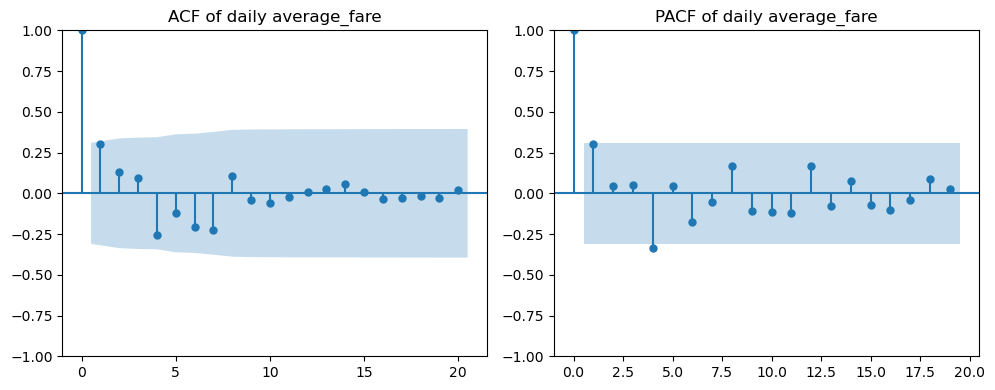

In [25]:
# 7.2 ACF and PACF of daily average_fare

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Use the same y as in the SARIMAX training section (average_fare per day)
# If this cell is run standalone, re-load from the daily features table
if 'y' not in globals():
    features_df = spark.read.table(daily_features_table).orderBy("pickup_date")
    features_pd = features_df.toPandas()
    features_pd["pickup_date"] = pd.to_datetime(features_pd["pickup_date"])
    features_pd.set_index("pickup_date", inplace=True)
    features_pd.sort_index(inplace=True)
    y = features_pd["average_fare"].astype(float).dropna()

# Optionally, you could difference y here for stationarity inspection, e.g.:
# y_diff = y.diff().dropna()
# For simplicity we inspect the undifferenced series
y_diff = y

n = len(y_diff)
# Ensure PACF lags respect the 50% rule and we have at least 2 lags
max_pacf_lags = max(1, min(20, n // 2 - 1))

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(y_diff, lags=min(20, n - 1), ax=ax[0])
ax[0].set_title("ACF of daily average_fare")

plot_pacf(y_diff, lags=max_pacf_lags, ax=ax[1])
ax[1].set_title("PACF of daily average_fare")

plt.tight_layout()
plt.show()

## 7.3 ACF and PACF of SARIMAX residuals

We analyze the residuals of the fitted SARIMAX model. If the model is well specified, residuals should resemble white noise:

- Residuals should be roughly centered around zero.
- ACF/PACF of residuals should show no strong autocorrelation.
- Ljung–Box test should not strongly reject the white-noise hypothesis at typical lags.

StatementMeta(, 6034f1e1-3cd9-4633-ba73-a85805a0e93c, 29, Finished, Available, Finished, False)

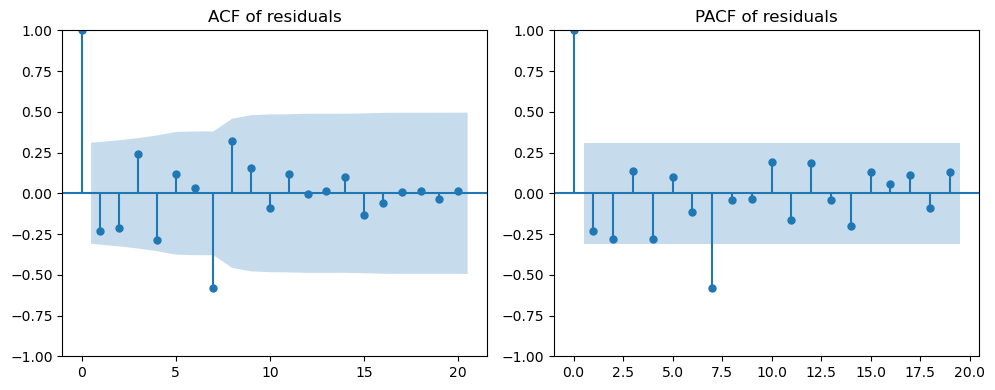

Ljung–Box test on residuals:
      lb_stat  lb_pvalue
10  35.877660   0.000088
20  38.933597   0.006795


In [26]:
# 7.3 ACF and PACF of SARIMAX residuals + Ljung–Box test

from statsmodels.stats.diagnostic import acorr_ljungbox

# Ensure we have a fitted SARIMAX result; if not, raise a clear error
if 'sarimax_result' not in globals():
    raise RuntimeError("sarimax_result is not defined. Run the SARIMAX training cells (section 4.4) before this cell.")

residuals = sarimax_result.resid
n_resid = len(residuals)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
plot_acf(residuals, lags=min(20, n_resid - 1), ax=ax[0])
ax[0].set_title("ACF of residuals")

max_pacf_lags_resid = max(1, min(20, n_resid // 2 - 1))
plot_pacf(residuals, lags=max_pacf_lags_resid, ax=ax[1])
ax[1].set_title("PACF of residuals")

plt.tight_layout()
plt.show()

# Ljung–Box test at a couple of horizons (cap at available length)
max_lag_for_test = max(1, min(20, n_resid - 1))

ljung = acorr_ljungbox(residuals, lags=[min(10, max_lag_for_test), max_lag_for_test], return_df=True)
print("Ljung–Box test on residuals:")
print(ljung)